## Consuming data using Kafka and Visualise (20%)
In this task, we will implement an Apache Kafka consumer to consume the data from Part 2.  
  
Important:   
-	In this part, Kafka consumers are used to consume the streaming data published from task 2.8.

In [1]:
# Install folium if it is not already available
# Run this cell once before the dashboard code.

try:
    import folium
    print("folium is already installed.")
except ModuleNotFoundError:
    %pip install folium
    import folium
    print("folium installed successfully.")

folium is already installed.


In [2]:
import json
import time
from kafka import KafkaConsumer

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import folium

from IPython.display import clear_output, display

# Kafka broker
bootstrap_servers = "kafka:9092"

# Kafka topics created from Task 2 Question 8
high_severity_topic = "q8_high_severity_accidents"
severity_count_topic = "q8_severity_count"
area_severity_topic = "q8_area_severity_count"

In [3]:
# Dashboard consumer for multiple Kafka topics

def create_dashboard_consumer(topic_names, group_id, offset_reset="latest"):
    """
    Create one Kafka consumer that listens to multiple Kafka topics.
    Use offset_reset='latest' for live dashboard testing.
    Use offset_reset='earliest' only when replaying old Kafka messages.
    """
    try:
        consumer = KafkaConsumer(
            *topic_names,
            bootstrap_servers=bootstrap_servers,
            auto_offset_reset=offset_reset,
            enable_auto_commit=True,
            group_id=group_id,
            consumer_timeout_ms=1000,
            value_deserializer=lambda message: json.loads(message.decode("utf-8"))
        )

        print("Dashboard Kafka consumer created successfully.")
        print("Listening to topics:", topic_names)
        return consumer

    except Exception as error:
        print("Error creating dashboard Kafka consumer.")
        print("Error message:", error)
        return None

2. Create a dashboard with 3 plots to visualise the real-time streaming data from part 2:  
a) A basic plot to show the number of high-severity accidents (line/bar chart).  
b) A histogram shows the cumulative distribution of accidents by severity.  
c) A bubble map plot similar to UK Road Traffic Accidents - Crash View. (Just the map; no interactive controllers are required. You can use any library (like folium, seaborn, plotly, etc.)

Note: Ideally, for a dashboard-like user experience, 3 diagrams need to be updated in real-time simultaneously. You may need to do a bit of searching/research to make it work.

In [4]:
# Professional real-time accident dashboard

def create_uk_bubble_map(district_bubble_df):
    """
    Create an actual UK map using folium.
    Each bubble represents a local district.
    Bubble size is based on total accident count.
    """
    # Create UK-centered map
    uk_map = folium.Map(
        location=[54.5, -2.5],
        zoom_start=6,
        tiles="OpenStreetMap"
    )

    if len(district_bubble_df) == 0:
        return uk_map

    map_df = district_bubble_df.dropna(
        subset=["district_latitude", "district_longitude", "total_accidents"]
    ).copy()

    if len(map_df) == 0:
        return uk_map

    max_accidents = map_df["total_accidents"].max()

    for _, row in map_df.iterrows():
        if max_accidents > 0:
            radius_value = 5 + (row["total_accidents"] / max_accidents) * 25
        else:
            radius_value = 6

        popup_text = (
            f"<b>District:</b> {row['local_district']}<br>"
            f"<b>Total accidents:</b> {int(row['total_accidents'])}<br>"
            f"<b>High-severity accidents:</b> {int(row['high_severity_count'])}"
        )

        folium.CircleMarker(
            location=[
                row["district_latitude"],
                row["district_longitude"]
            ],
            radius=radius_value,
            popup=popup_text,
            tooltip=(
                f"{row['local_district']} | "
                f"Total: {int(row['total_accidents'])}"
            ),
            fill=True,
            fill_opacity=0.55,
            opacity=0.75
        ).add_to(uk_map)

    return uk_map


def run_accident_dashboard(consumer):
    high_severity_records = []
    severity_count_records = []
    area_severity_records = []

    # Timeline for Plot A.
    # This records when the dashboard observes the current high-severity count.
    high_count_timeline = []

    try:
        while True:
            # Read available messages from all subscribed Kafka topics
            for message in consumer:
                topic_name = message.topic
                message_value = message.value

                if topic_name == high_severity_topic:
                    high_severity_records.append(message_value)

                elif topic_name == severity_count_topic:
                    severity_count_records.append(message_value)

                elif topic_name == area_severity_topic:
                    area_severity_records.append(message_value)

            clear_output(wait=True)

            # -----------------------------
            # Prepare Plot A data
            # High-severity accidents over dashboard observation time
            # -----------------------------
            if len(high_severity_records) > 0:
                high_df = pd.DataFrame(high_severity_records)

                high_df["event_time"] = pd.to_datetime(
                    high_df["event_time"],
                    errors="coerce"
                )

                high_df = high_df.dropna(subset=["event_time"])

                # Keep one row per collision_index to avoid duplicate accident IDs
                distinct_high_df = (
                    high_df
                    .sort_values("event_time")
                    .drop_duplicates(subset=["collision_index"], keep="last")
                    .sort_values("event_time")
                )

                distinct_high_count = distinct_high_df["collision_index"].nunique()

            else:
                distinct_high_df = pd.DataFrame()
                distinct_high_count = 0

            # Store dashboard observation time and cumulative distinct high-severity count
            high_count_timeline.append({
                "observation_time": pd.Timestamp.now(),
                "distinct_high_severity_count": distinct_high_count
            })

            high_time_df = pd.DataFrame(high_count_timeline)

            # Keep recent observations only so the plot remains readable
            if len(high_time_df) > 60:
                high_time_df = high_time_df.tail(60).reset_index(drop=True)
                high_count_timeline = high_time_df.to_dict("records")

            # -----------------------------
            # Prepare Plot B data
            # Cumulative severity distribution
            # -----------------------------
            if len(severity_count_records) > 0:
                severity_df = pd.DataFrame(severity_count_records)

                severity_df["predicted_severity"] = pd.to_numeric(
                    severity_df["predicted_severity"],
                    errors="coerce"
                )

                severity_df["total_accidents"] = pd.to_numeric(
                    severity_df["total_accidents"],
                    errors="coerce"
                )

                severity_distribution_df = (
                    severity_df
                    .dropna(subset=["predicted_severity", "total_accidents"])
                    .groupby("predicted_severity", as_index=False)["total_accidents"]
                    .sum()
                    .sort_values("predicted_severity")
                )

                severity_distribution_df["predicted_severity"] = (
                    severity_distribution_df["predicted_severity"].astype(int)
                )

                total_accidents = int(severity_distribution_df["total_accidents"].sum())

                if len(severity_distribution_df) > 0:
                    most_common_severity = int(
                        severity_distribution_df
                        .sort_values("total_accidents", ascending=False)
                        .iloc[0]["predicted_severity"]
                    )
                else:
                    most_common_severity = "N/A"

            else:
                severity_distribution_df = pd.DataFrame(
                    columns=["predicted_severity", "total_accidents"]
                )
                total_accidents = 0
                most_common_severity = "N/A"

            # -----------------------------
            # Prepare Plot C data
            # Total accident bubble map by district from Q8 Stream 3
            # -----------------------------
            if len(area_severity_records) > 0:
                area_df = pd.DataFrame(area_severity_records)

                numeric_cols = [
                    "total_accidents",
                    "low_severity_count",
                    "medium_severity_count",
                    "high_severity_count",
                    "district_latitude",
                    "district_longitude"
                ]

                for col_name in numeric_cols:
                    if col_name in area_df.columns:
                        area_df[col_name] = pd.to_numeric(
                            area_df[col_name],
                            errors="coerce"
                        )

                district_bubble_df = (
                    area_df
                    .dropna(
                        subset=[
                            "local_district",
                            "district_latitude",
                            "district_longitude",
                            "total_accidents"
                        ]
                    )
                    .groupby("local_district", as_index=False)
                    .agg(
                        total_accidents=("total_accidents", "sum"),
                        high_severity_count=("high_severity_count", "sum"),
                        district_latitude=("district_latitude", "mean"),
                        district_longitude=("district_longitude", "mean")
                    )
                    .sort_values("total_accidents", ascending=False)
                )

                active_districts = district_bubble_df["local_district"].nunique()

            else:
                district_bubble_df = pd.DataFrame(
                    columns=[
                        "local_district",
                        "total_accidents",
                        "high_severity_count",
                        "district_latitude",
                        "district_longitude"
                    ]
                )
                active_districts = 0

            # -----------------------------
            # Dashboard summary
            # -----------------------------
            print("Real-Time UK Road Accident Severity Dashboard")
            print("=" * 55)
            print(f"Total accidents: {total_accidents:,}")
            print(f"Distinct high-severity accidents: {distinct_high_count:,}")
            print(f"Active districts: {active_districts:,}")
            print(f"Most common severity: {most_common_severity}")
            print(f"High-severity messages received: {len(high_severity_records):,}")
            print(f"Severity-count messages received: {len(severity_count_records):,}")
            print(f"District severity messages received: {len(area_severity_records):,}")

            # -----------------------------
            # Top dashboard: Plot A and Plot B
            # -----------------------------
            fig = plt.figure(figsize=(18, 7))

            fig.suptitle(
                "Real-Time UK Road Accident Severity Dashboard",
                fontsize=18,
                fontweight="bold",
                y=1.03
            )

            summary_text = (
                f"Total Accidents: {total_accidents:,}     "
                f"High-Severity Accidents: {distinct_high_count:,}     "
                f"Active Districts: {active_districts:,}     "
                f"Most Common Severity: {most_common_severity}"
            )

            fig.text(
                0.5,
                0.94,
                summary_text,
                ha="center",
                va="center",
                fontsize=12,
                fontweight="bold",
                bbox=dict(
                    boxstyle="round,pad=0.6",
                    edgecolor="black",
                    facecolor="#f2f2f2"
                )
            )

            ax1 = plt.subplot2grid((1, 2), (0, 0))
            ax2 = plt.subplot2grid((1, 2), (0, 1))

            # -----------------------------
            # Plot A: high-severity count over observation time
            # -----------------------------
            if len(high_time_df) > 0:
                ax1.step(
                    high_time_df["observation_time"],
                    high_time_df["distinct_high_severity_count"],
                    where="post",
                    marker="o",
                    linewidth=2
                )

                ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H-%M-%S"))
                ax1.tick_params(axis="x", rotation=45)

            ax1.set_title(
                "(a) High-Severity Accidents Over Time",
                fontweight="bold"
            )
            ax1.set_xlabel("Observation time (HH-MM-SS)")
            ax1.set_ylabel("Distinct high-severity accident count")
            ax1.grid(True, alpha=0.3)

            # -----------------------------
            # Plot B: cumulative distribution by severity
            # -----------------------------
            if len(severity_distribution_df) > 0:
                ax2.bar(
                    severity_distribution_df["predicted_severity"],
                    severity_distribution_df["total_accidents"]
                )

                ax2.set_xticks(severity_distribution_df["predicted_severity"])

            ax2.set_title(
                "(b) Cumulative Distribution by Predicted Severity",
                fontweight="bold"
            )
            ax2.set_xlabel("Predicted severity")
            ax2.set_ylabel("Total accidents")
            ax2.grid(True, axis="y", alpha=0.3)

            plt.tight_layout(rect=[0, 0, 1, 0.88])
            plt.show()

            # -----------------------------
            # Plot C: actual UK bubble map using folium
            # -----------------------------
            print("\n(c) Bubble Map of Total Accidents by Local District")
            uk_map = create_uk_bubble_map(district_bubble_df)
            display(uk_map)

            # Refresh every 5 seconds
            time.sleep(5)

    except KeyboardInterrupt:
        print("Dashboard stopped by user.")

    finally:
        if consumer is not None:
            consumer.close()
            print("Kafka dashboard consumer closed.")

Real-Time UK Road Accident Severity Dashboard
Total accidents: 17,643
Distinct high-severity accidents: 0
Active districts: 51
Most common severity: 4
High-severity messages received: 0
Severity-count messages received: 133
District severity messages received: 632


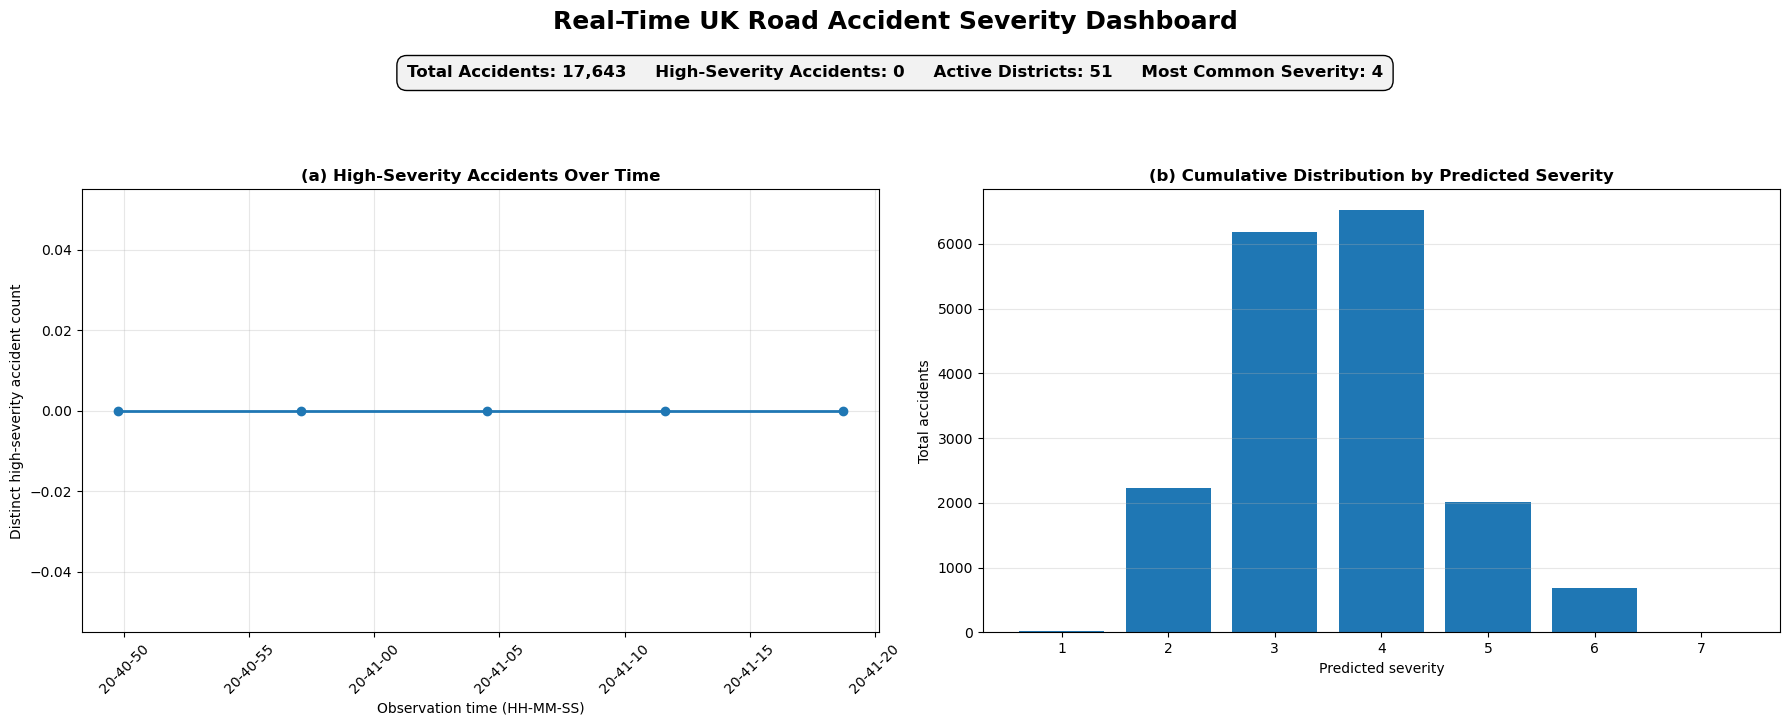


(c) Bubble Map of Total Accidents by Local District


Dashboard stopped by user.
Kafka dashboard consumer closed.


In [5]:
# Start final real-time dashboard

dashboard_consumer = create_dashboard_consumer(
    topic_names=[
        high_severity_topic,
        severity_count_topic,
        area_severity_topic
    ],
    group_id="task3_final_dashboard_group",
    offset_reset="latest"
)

if dashboard_consumer is not None:
    run_accident_dashboard(dashboard_consumer)